# Roman Urdu Sentiment Classifier — Training Notebook
Run this in **Google Colab** with a GPU: `Runtime → Change runtime type → T4 GPU`.

Plan:
1. Setup and load data
2. Clean and explore data
3. Split into train / validation / test
4. Baseline: TF-IDF + Logistic Regression
5. Fine-tune a multilingual transformer
6. Evaluate on the test set and compare
7. Error analysis
8. Save the model (Google Drive + Hugging Face Hub)

## 1. Setup
Check the GPU. If you see an error here, your runtime has no GPU.

In [1]:
!nvidia-smi

Fri Sep 25 23:07:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip -q install -U transformers datasets accelerate scikit-learn ucimlrepo
import transformers; print("transformers", transformers.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 135.4 MB/s eta 0:00:00
transformers 5.17.0


In [3]:
# Save everything to Google Drive so a Colab disconnect does not lose your work.
from google.colab import drive
drive.mount('/content/drive')

import os
OUT_DIR = "/content/drive/MyDrive/roman-urdu-sentiment"
os.makedirs(OUT_DIR, exist_ok=True)

Mounted at /content/drive


In [4]:
import json, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

### Cleaning functions
This is a copy of `src/preprocess.py` from the repo. **Keep them identical** —
if training and serving clean text differently, accuracy silently drops
(this is called *training-serving skew*).

In [5]:
import re

LABELS = ["negative", "neutral", "positive"]          # index = label id
LABEL2ID = {name: i for i, name in enumerate(LABELS)}
ID2LABEL = {i: name for i, name in enumerate(LABELS)}

_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_MENTION_RE = re.compile(r"@\w+")
_REPEAT_RE = re.compile(r"(.)\1{2,}")                  # 3+ same chars in a row
_SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Normalise one Roman Urdu sentence.

    Steps and reasons:
    1. lowercase          -> "Acha" and "acha" become the same word
    2. remove URLs        -> links carry no sentiment, only noise
    3. remove @mentions   -> usernames carry no sentiment
    4. squash repeats     -> "bohttttt" -> "bohtt", so spelling stretches
                             map to fewer variants
    5. collapse spaces    -> tidy whitespace

    We do NOT remove punctuation like "!" or "?" because it can carry
    emotion ("zabardast!!").
    """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = _URL_RE.sub(" ", text)
    text = _MENTION_RE.sub(" ", text)
    text = _REPEAT_RE.sub(r"\1\1", text)
    text = _SPACE_RE.sub(" ", text)
    return text.strip()


def normalise_label(raw) -> str | None:
    """Map messy raw labels to one of LABELS, or None if unknown.

    The original dataset has a few typos (for example "Neative"), so we
    fix known ones and drop anything we cannot trust.
    """
    if raw is None:
        return None
    label = str(raw).strip().lower()
    fixes = {"neative": "negative"}
    label = fixes.get(label, label)
    return label if label in LABEL2ID else None

## 2. Load the dataset
Roman Urdu Data Set (Sharf, 2017), ~20k sentences labelled Positive / Negative / Neutral. License: CC BY 4.0 on UCI.

In [6]:
from datasets import load_dataset
try:
    ds = load_dataset("community-datasets/roman_urdu", split="train")
    names = ds.features["sentiment"].names
    df = pd.DataFrame({"text": ds["sentence"],
                       "raw_label": [names[i] for i in ds["sentiment"]]})
    print("Loaded from Hugging Face Hub")
except Exception as e:
    print("Hub failed, trying UCI:", e)
    from ucimlrepo import fetch_ucirepo
    raw = fetch_ucirepo(id=458).data.original
    df = pd.DataFrame({"text": raw.iloc[:, 0].astype(str),
                       "raw_label": raw.iloc[:, 1]})

print(df.shape)
df.head(10)

README.md:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.06MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20229 [00:00<?, ? examples/s]

Loaded from Hugging Face Hub
(20229, 2)


,text,raw_label
0,Sai kha ya her kisi kay bus ki bat nhi hai lak...,Positive
1,sahi bt h,Positive
2,"Kya bt hai,",Positive
3,Wah je wah,Positive
4,Are wha kaya bat hai,Positive
5,Wah kya baat likhi,Positive
6,Wha Itni sari khubiya,Positive
7,Itni khubiya,Positive
8,Ya allah rehm farma hm sab pe or zalimo ko hid...,Positive
9,Please Everyone AllAh S.w.T ka naam hAmesha Ba...,Positive


## 3. Clean and explore

In [7]:
n0 = len(df)
df["label_name"] = df["raw_label"].map(normalise_label)
df["text"] = df["text"].map(clean_text)
df = df.dropna(subset=["label_name"])
df = df[df["text"].str.len() > 0]

# Same sentence with DIFFERENT labels = annotators disagreed. We cannot trust it, so drop it.
conflict = df.groupby("text")["label_name"].nunique()
conflict_texts = set(conflict[conflict > 1].index)
df = df[~df["text"].isin(conflict_texts)].drop_duplicates(subset="text")

df["label"] = df["label_name"].map(LABEL2ID)
print(f"Rows: {n0} -> {len(df)}  (conflicting texts removed: {len(conflict_texts)})")
print(df["label_name"].value_counts())

Rows: 20229 -> 19476  (conflicting texts removed: 29)
label_name
neutral     8433
positive    5809
negative    5234
Name: count, dtype: int64


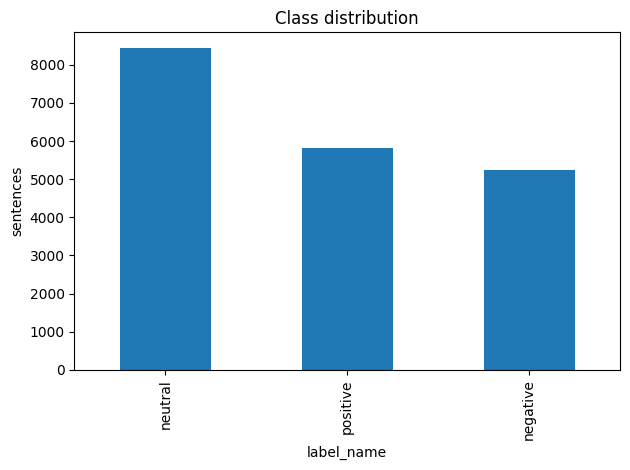

count    19476.000000
mean        13.557353
std         13.221178
min          1.000000
25%          6.000000
50%         10.000000
75%         17.000000
max        301.000000
Name: n_words, dtype: float64


In [8]:
counts = df["label_name"].value_counts()
counts.plot(kind="bar", title="Class distribution")
plt.ylabel("sentences"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/class_distribution.png", dpi=150); plt.show()

df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe())

## 4. Split: train 80% / validation 10% / test 10%
`stratify` keeps the same class ratio in every split. The **test set is used only once, at the very end**.

In [9]:
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)
print(len(train_df), len(val_df), len(test_df))

15580 1948 1948


## 5. Baseline: TF-IDF + Logistic Regression
Word n-grams catch phrases (`bohat acha`). Character n-grams catch spelling variants (`bohat / bahut / bht`), which is very common in Roman Urdu.

In [10]:
results = {}

def evaluate(name, y_true, y_pred, fig_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    results[name] = {"accuracy": round(acc, 4), "f1_macro": round(f1, 4)}
    print(f"{name}: accuracy={acc:.4f}  macro-F1={f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=LABELS,
                                            cmap="Blues", normalize="true", values_format=".2f")
    plt.title(f"{name} (test set, row-normalised)")
    plt.savefig(f"{OUT_DIR}/{fig_name}", dpi=150, bbox_inches="tight"); plt.show()

Baseline trained in 20.5s
Validation macro-F1: 0.6770729602367945
TF-IDF + LogReg: accuracy=0.6781  macro-F1=0.6725

              precision    recall  f1-score   support

    negative     0.5915    0.6355    0.6127       524
     neutral     0.7391    0.6821    0.7094       843
    positive     0.6804    0.7108    0.6953       581

    accuracy                         0.6781      1948
   macro avg     0.6703    0.6761    0.6725      1948
weighted avg     0.6819    0.6781    0.6792      1948



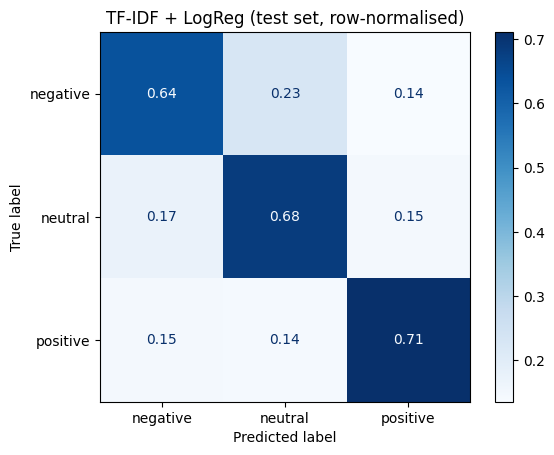

['/content/drive/MyDrive/roman-urdu-sentiment/baseline.joblib']

In [11]:
from sklearn.pipeline import make_pipeline, make_union
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

baseline = make_pipeline(
    make_union(
        TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=2, sublinear_tf=True),
        TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True),
    ),
    LogisticRegression(max_iter=2000, class_weight="balanced"),
)
t = time.time()
baseline.fit(train_df["text"], train_df["label"])
print(f"Baseline trained in {time.time()-t:.1f}s")

print("Validation macro-F1:", f1_score(val_df["label"], baseline.predict(val_df["text"]), average="macro"))
evaluate("TF-IDF + LogReg", test_df["label"], baseline.predict(test_df["text"]), "baseline_confusion.png")
joblib.dump(baseline, f"{OUT_DIR}/baseline.joblib")

## 6. Fine-tune a multilingual transformer
`distilbert-base-multilingual-cased`: pre-trained on 100+ languages, smaller and faster than BERT.
Swap in `xlm-roberta-base` later if you have more time (usually stronger, ~2× slower).

**If you get an error about arguments:** very old `transformers` versions use
`evaluation_strategy` instead of `eval_strategy`, and `tokenizer=` instead of `processing_class=`.

In [12]:
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer)

MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LENGTH = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# How many sentences are longer than MAX_LENGTH tokens? (should be a tiny %)
lens = [len(tokenizer(t)["input_ids"]) for t in train_df["text"].sample(2000, random_state=SEED)]
print(f"95th percentile tokens: {np.percentile(lens, 95):.0f}; >{MAX_LENGTH}: {np.mean(np.array(lens) > MAX_LENGTH):.2%}")

def to_ds(frame):
    ds = Dataset.from_pandas(frame[["text", "label"]].reset_index(drop=True))
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LENGTH), batched=True)

train_ds, val_ds, test_ds = to_ds(train_df), to_ds(val_df), to_ds(test_df)

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (638 > 512). Running this sequence through the model will result in indexing errors


95th percentile tokens: 67; >128: 0.65%


Map:   0%|          | 0/15580 [00:00<?, ? examples/s]

Map:   0%|          | 0/1948 [00:00<?, ? examples/s]

Map:   0%|          | 0/1948 [00:00<?, ? examples/s]

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir="/content/checkpoints",
    eval_strategy="epoch",            # evaluate on validation after every epoch
    save_strategy="epoch",
    learning_rate=2e-5,               # small: we only nudge pre-trained weights
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,                # mild regularisation against overfitting
    load_best_model_at_end=True,      # keep the epoch with best validation F1
    metric_for_best_model="f1_macro",
    save_total_limit=1,
    fp16=torch.cuda.is_available(),   # mixed precision: faster on T4
    logging_steps=50,
    report_to="none",                 # no wandb login prompts
    seed=SEED,
)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  processing_class=tokenizer, data_collator=DataCollatorWithPadding(tokenizer),
                  compute_metrics=compute_metrics)
t = time.time()
trainer.train()
print(f"Fine-tuning took {(time.time()-t)/60:.1f} min")

model.safetensors: reconstructing file:   0%|          |  0.00B /  542MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.909955,0.876909,0.601129,0.585499
2,0.772232,0.848696,0.622177,0.610560
3,0.674740,0.848051,0.634497,0.626718


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning took 3.5 min


## 7. Final test-set evaluation and comparison

DistilBERT-multilingual (fine-tuned): accuracy=0.6437  macro-F1=0.6284

              precision    recall  f1-score   support

    negative     0.5794    0.4943    0.5335       524
     neutral     0.6991    0.7082    0.7036       843
    positive     0.6151    0.6850    0.6482       581

    accuracy                         0.6437      1948
   macro avg     0.6312    0.6292    0.6284      1948
weighted avg     0.6419    0.6437    0.6413      1948



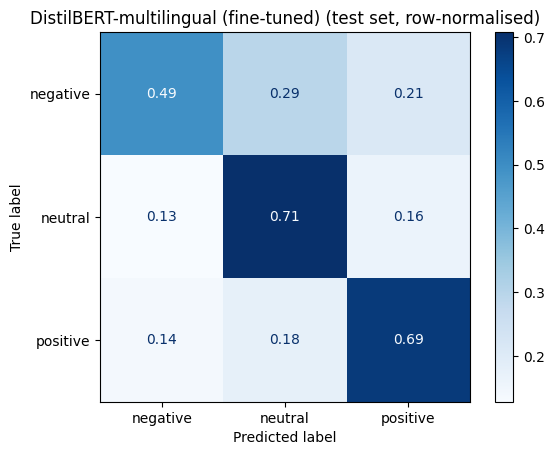

                                      accuracy  f1_macro
TF-IDF + LogReg                         0.6781    0.6725
DistilBERT-multilingual (fine-tuned)    0.6437    0.6284


In [14]:
pred_out = trainer.predict(test_ds)
test_probs = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()
test_pred = test_probs.argmax(axis=1)
evaluate("DistilBERT-multilingual (fine-tuned)", test_df["label"], test_pred, "transformer_confusion.png")

comparison = pd.DataFrame(results).T
print(comparison)
with open(f"{OUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)

## 8. Error analysis
Look at what the model gets wrong. **Wrong but very confident** predictions are often
*label noise* (the dataset label itself is questionable) — a great interview talking point.

In [15]:
err = test_df[["text", "label_name"]].copy()
err["pred"] = [ID2LABEL[i] for i in test_pred]
err["confidence"] = test_probs.max(axis=1).round(3)
wrong = err[err["label_name"] != err["pred"]]
print(f"Wrong: {len(wrong)} / {len(err)}")
pd.set_option("display.max_colwidth", 120)
print("\nMost confident mistakes:")
display(wrong.sort_values("confidence", ascending=False).head(15))
print("\nMost common confusions:")
print(wrong.groupby(["label_name", "pred"]).size().sort_values(ascending=False))

Wrong: 694 / 1948

Most confident mistakes:


,text,label_name,pred,confidence
10603,somebody tell me why?,negative,neutral,0.969
15925,aoa hazrat je ap s khasosi dua ki darkhwast h. allaha ap ko jazay khair dy ameen,negative,positive,0.967
9685,beshak waalaikumassalam app sab ko bhi jumma mubarak inshaallah zaror dua main yad rakhe gy,neutral,positive,0.967
112,aala :d :d,positive,neutral,0.966
10567,dushmn 😂🙌,negative,neutral,0.965
400,hehee,positive,neutral,0.963
16177,allah apko jazaye khair dy hazrat sb,neutral,positive,0.962
12662,lajewab ..,negative,neutral,0.960
12263,allah ko yaad kar k naik bannay k bjay apna tamasha bana rahy hen . allah hidayat da,negative,positive,0.959
3113,ala,positive,neutral,0.957



Most common confusions:
label_name  pred    
negative    neutral     154
neutral     positive    138
negative    positive    111
neutral     negative    108
positive    neutral     103
            negative     80
dtype: int64


## 9. Save the model

In [16]:
SAVE_DIR = f"{OUT_DIR}/model"
trainer.save_model(SAVE_DIR)          # the best checkpoint (load_best_model_at_end)
tokenizer.save_pretrained(SAVE_DIR)
print("Saved to", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/roman-urdu-sentiment/model


In [5]:
# Session restarted, so reload the saved model from Google Drive and upload it
from google.colab import drive
drive.mount('/content/drive')

import os, json
from transformers import AutoModelForSequenceClassification, AutoTokenizer

OUT_DIR = "/content/drive/MyDrive/roman-urdu-sentiment"
SAVE_DIR = f"{OUT_DIR}/model"
print("Files in Drive folder:", os.listdir(OUT_DIR))

# Show your saved test results (section 7 numbers)
with open(f"{OUT_DIR}/results.json") as f:
    print(json.dumps(json.load(f), indent=2))

model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)

HUB_ID = "aleenakhurshid/roman-urdu-sentiment"
model.push_to_hub(HUB_ID)
tokenizer.push_to_hub(HUB_ID)
print("Uploaded! Check https://huggingface.co/" + HUB_ID)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in Drive folder: ['class_distribution.png', 'baseline_confusion.png', 'baseline.joblib', 'transformer_confusion.png', 'results.json', 'model']
{
  "TF-IDF + LogReg": {
    "accuracy": 0.6781,
    "f1_macro": 0.6725
  },
  "DistilBERT-multilingual (fine-tuned)": {
    "accuracy": 0.6437,
    "f1_macro": 0.6284
  }
}


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...39xnupc/model.safetensors:   3%|2         | 16.0MB /  541MB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded! Check https://huggingface.co/aleenakhurshid/roman-urdu-sentiment


Upload to Hugging Face Hub (needed for the live demo). Create a **write** token at huggingface.co → Settings → Access Tokens.

In [6]:
from huggingface_hub import login
login()                                # paste your token when asked

HUB_ID = "aleenakhurshid/roman-urdu-sentiment"   # <-- change this
trainer.model.push_to_hub(HUB_ID)
tokenizer.push_to_hub(HUB_ID)

NameError: name 'trainer' is not defined

## 10. Sanity check with your own sentences

In [ ]:
def predict(texts):
    enc = tokenizer([clean_text(t) for t in texts], padding=True, truncation=True,
                    max_length=MAX_LENGTH, return_tensors="pt").to(trainer.model.device)
    with torch.no_grad():
        probs = torch.softmax(trainer.model(**enc).logits, dim=-1).cpu().numpy()
    for t, p in zip(texts, probs):
        print(f"{ID2LABEL[p.argmax()]:>8} ({p.max():.2f})  {t}")

predict(["mera balance bina wajah kat gaya, bohat bura experience",
         "delivery time pe aa gayi, shukriya",
         "package ka rate kya hai?",
         "yar net itna slow kyun hai aaj"])